In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [3]:
# create the dataset

np.random.seed(42)

data = {
    'product_id': range(1,21),
    'product_name': [f'Product{i}' for i in range(1,21)],
    'category' : np.random.choice(['Electronic', 'Clothing', 'Home', 'Sports'], 20),
    'units_sold': np.random.poisson(lam=20, size=20),#poisson is a type of distribution
    'sales_data': pd.date_range(start= '2023-01-01', periods=20, freq='D'),
}

sales_data = pd.DataFrame(data)

print('Sales Data: ')
print(sales_data)

Sales Data: 
    product_id product_name    category  units_sold sales_data
0            1     Product1        Home          25 2023-01-01
1            2     Product2      Sports          15 2023-01-02
2            3     Product3  Electronic          17 2023-01-03
3            4     Product4        Home          19 2023-01-04
4            5     Product5        Home          21 2023-01-05
5            6     Product6      Sports          17 2023-01-06
6            7     Product7  Electronic          19 2023-01-07
7            8     Product8  Electronic          16 2023-01-08
8            9     Product9        Home          21 2023-01-09
9           10    Product10    Clothing          21 2023-01-10
10          11    Product11        Home          17 2023-01-11
11          12    Product12        Home          22 2023-01-12
12          13    Product13        Home          14 2023-01-13
13          14    Product14        Home          17 2023-01-14
14          15    Product15      Sports   

In [8]:
# save the dataframe to csv file
sales_data.to_csv('sales.dataa.csv', index=False)

In [ ]:
import os
os.getcwd()


In [13]:
# descriptive stats

desccriptive_stats = sales_data['units_sold'].describe()

print("\nDescriptive Statistics for Unites sold: ")
print(desccriptive_stats)

mean_sales=sales_data['units_sold'].mean()
median_sales=sales_data['units_sold'].median()
mode_sales=sales_data['units_sold'].mode()[0]
variance_sales=sales_data['units_sold'].var()
std_sales=sales_data['units_sold'].std()

category_stats = sales_data.groupby('category')['units_sold'].agg(['sum', 'mean', 'std']).reset_index()
print(f"Mean Units Sold: {mean_sales}")
print(f"Median Units Sold: {median_sales}")
print(f"Mode Units Sold: {mode_sales}")
print(f"Variance Units Sold: {variance_sales}")
print(f"Standard Deviation Units Sold: {std_sales}")

print("\nCategory Statistics")
print(category_stats)



Descriptive Statistics for Unites sold: 
count    20.000000
mean     18.800000
std       3.302312
min      13.000000
25%      17.000000
50%      18.500000
75%      21.000000
max      25.000000
Name: units_sold, dtype: float64
Mean Units Sold: 18.8
Median Units Sold: 18.5
Mode Units Sold: 17
Variance Units Sold: 10.90526315789474
Standard Deviation Units Sold: 3.3023117899275864

Category Statistics
     category  sum       mean       std
0    Clothing   21  21.000000       NaN
1  Electronic   73  18.250000  2.217356
2        Home  181  20.111111  3.723051
3      Sports  101  16.833333  2.714160


In [ ]:
# Inferiential Stats
# Probability and Distribution
# Distributions Graph is created from probability

# roll 1 dice = Uniform distributions
# Roll 2 dices = Normal distributions is formed. also called as bell curved dist = guasian distrbution

# Confidence Interval
# When we say that (95% confident that I'll get 80-85 marks)
# 80- lower interval -> also called (estimator)
# 85- Upper interval -> also called (estimator)
# mean - (90+95)/2 -> also called (estimates)

# Now if you get 84 -> accept the null hypothesis
# And if you get 87 -> Reject the null hypothesis

# 5% == 0.05 = p-value

# reject the null hypythessis = Far from the mean
# Accept the null hypothesis = Colse towards mean




In [14]:
# Inferiantial Stats

confidence_level = 0.95

degrees_freedom = len(sales_data['units_sold'])-1

# Polulation data = z-test
# Sample data = t-test

sample_mean=mean_sales
sample_std_error = std_sales / np.sqrt(len(sales_data['units_sold']))

# t-score

t_score = stats.t.ppf((1+confidence_level)/2, degrees_freedom)
margin_of_error = t_score * sample_std_error

confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print("\nCinfidence interval of the units sold")
print(confidence_interval)


Cinfidence interval of the units sold
(17.254470507823573, 20.34552949217643)


In [15]:
t_statistic, p_value = stats.ttest_1samp(sales_data['units_sold'], 20)

print("\n Hypothesis testing (t-test):")
print(f"T-statistics: {t_statistic}, p-value: {p_value}")

if p_value<0.05:
    print('reject the null hypothesis')
else:
    print('Fail tor reject the null hypo, means accepth the null hypo')
    
    
    


 Hypothesis testing (t-test):
T-statistics: -1.6250928099424466, p-value: 0.12061572226781002
Fail tor reject the null hypo, means accepth the null hypo


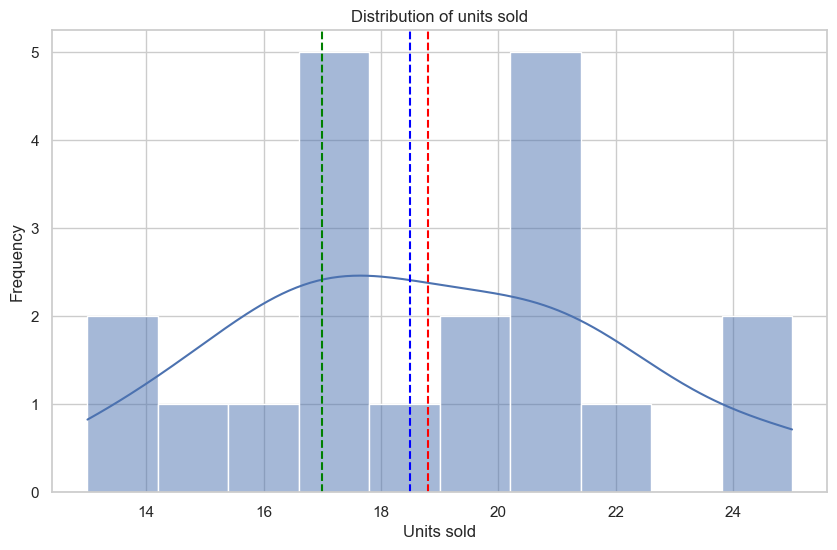

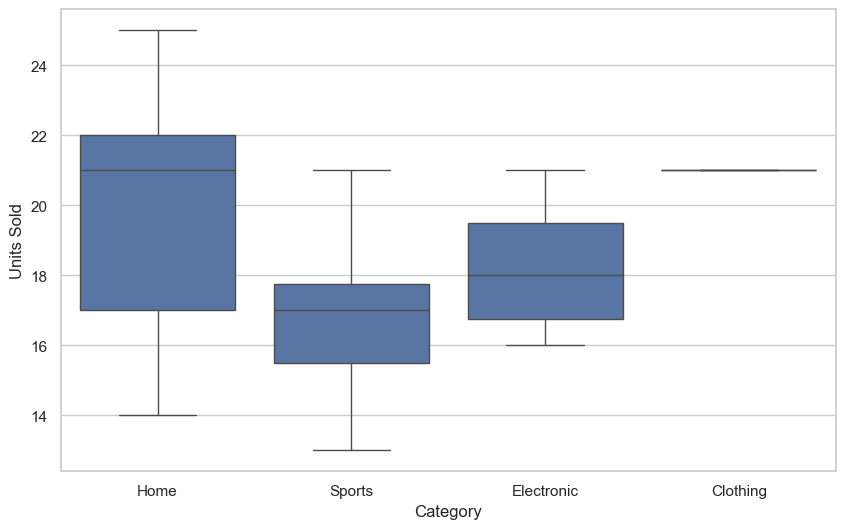

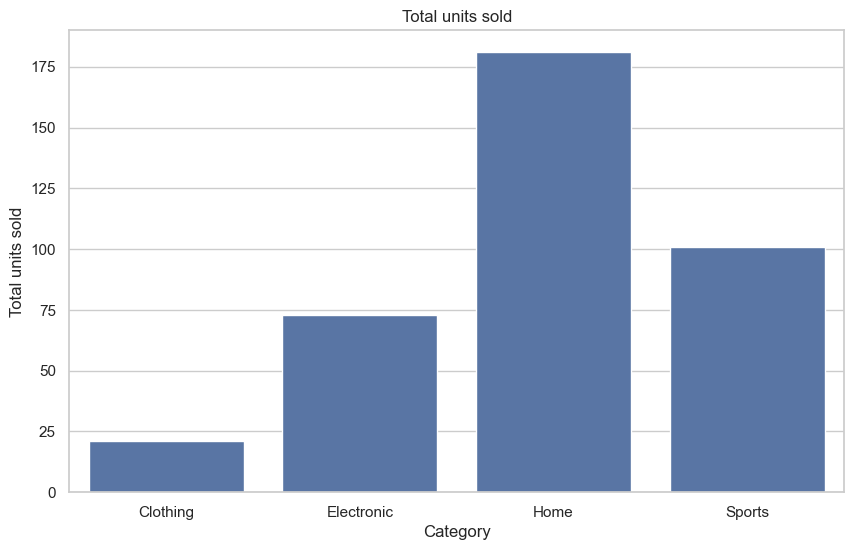

In [25]:
# visualization

sns.set(style='whitegrid')

#plot distribution of units sold
plt.figure(figsize=(10,6))
sns.histplot(sales_data['units_sold'], bins=10, kde=True)
plt.title('Distribution of units sold')
plt.xlabel('Units sold')
plt.ylabel('Frequency')
plt.axvline(mean_sales, color='red', linestyle='--', label = 'Mean')
plt.axvline(median_sales, color='blue', linestyle='--', label = 'Median')
plt.axvline(mode_sales, color='green', linestyle='--', label = 'Mode')
plt.legend
plt.show()

#Box Plot for units sold by category

plt.figure(figsize=(10,6))
sns.boxplot(x='category',y='units_sold', data=sales_data)
plt.xlabel('Category')
plt.ylabel('Units Sold')
plt.show()

# Create summary table
category_stats = sales_data.groupby('category', as_index=False)['units_sold'].sum()
category_stats.rename(columns={'units_sold': 'total_units_sold'}, inplace=True)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='category', y='total_units_sold', data=category_stats)
plt.title('Total units sold')
plt.xlabel('Category')
plt.ylabel('Total units sold')
plt.show()
